In [1]:
import subprocess, sys

for pkg in [
    ["torch==2.1.2", "torchvision==0.16.2", "--index-url", "https://download.pytorch.org/whl/cu118"],
    ["diffusers==0.31.0"],
    ["transformers==4.40.0"],
    ["accelerate==0.30.0"],
    ["numpy<2.0"],
    ["Pillow"]
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg)

In [2]:
import torch
import multiprocessing
from diffusers import StableDiffusionPipeline, DDIMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device == "cuda" else torch.float32

if device == "cpu":
    torch.set_num_threads(multiprocessing.cpu_count())

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
)

pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config,
    clip_sample=False,
    set_alpha_to_one=False
)

pipe = pipe.to(device)

if device == "cuda":
    pipe.enable_attention_slicing()

print(f"Device   : {device.upper()}")
print(f"Model    : stable-diffusion-v1-5")
print(f"Scheduler: DDIM")

/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.58it/s]


Device   : CUDA
Model    : stable-diffusion-v1-5
Scheduler: DDIM


  0%|          | 0/30 [00:00<?, ?it/s]/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 30/30 [00:05<00:00,  5.97it/s]


Saved: muslim_sd_forest.png


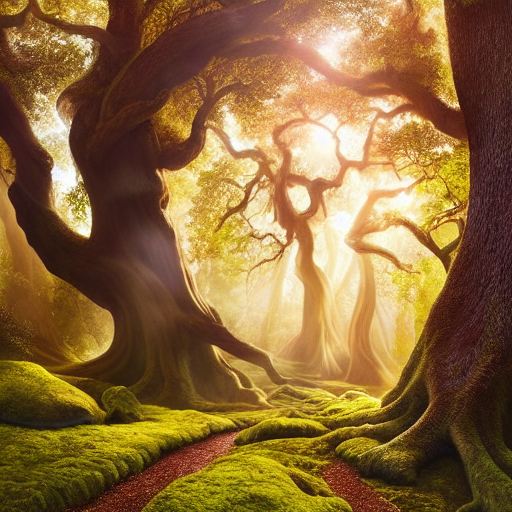

In [ ]:
import torch

prompt = (
    "A primordial enchanted forest at golden hour, colossal ancient oak trees "
    "with glowing amber moss, ethereal light beams piercing dense canopy, "
    "giant luminous mushrooms along a stone path, mystical morning mist, "
    "hyper-detailed fantasy illustration, rich earthy palette, award-winning art"
)

negative_prompt = (
    "urban, industrial, modern buildings, dark horror, ugly, "
    "poorly drawn, low resolution, jpeg artifacts"
)

gen = torch.Generator(device=device).manual_seed(3141)

output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=8.5,
    eta=0.0,
    width=512,
    height=512,
    generator=gen
)

img = output.images[0]
img.save("m_sd_forest.png")
print("Saved: mu_sd_forest.png")
img